### Схема работы Сиамской нейронной сети

<img src="images/Labs/II/scheme.png" alt="scheme" height=40% width=40%>

### Примеры использования

**Распознавание лиц**: При наличии двух отдельных изображений, содержащих лицо, позволяет определить один и тот же человек находится на обеих фотографиях или нет.

**Проверка подписи**: При наличии двух подписей определяет, является ли одна из них подделкой или нет.

**Идентификация таблеток**, отпускаемых по рецепту: При наличии двух таблеток, отпускаемых по рецепту, определияет, являются ли они одним и тем же лекарством или разными лекарствами.

и т.д.

### Популярные функции потерь при обучении сиамских сетей включают:

    
    - Binary cross-entropy
    - Triplet loss
    - Contrastive loss

<img src="images/Labs/II/i.jpeg" alt="scheme" height=60% width=70%>

### Binary cross-entropy loss

При использовании бинарной кросс-энтропии (BCELoss) в качестве лосс-функции, необходимо посчитать евклидово расстояние между двумя векторами, передать полученное значение в функцию активации sigmoid и сравнить с target-ом (1/0)

<img src="images/Labs/II/euclidean_distance.png" alt="scheme" height=40% width=40%>

### Contrastive loss function

При использовании Contrastive loss-функции, её необходимо реализовать самому

<img src="images/Labs/II/contrastive_loss.png" alt="scheme" height=40% width=40%>

**Y** : Метки из набора данных. Значение 1 указывает на то, что два изображения в паре относятся к одному классу, в то время как значение 0 указывает на то, что изображения принадлежат к двум разным классам.

**Dw**: расстояния между парами векторов (закодированных изображений).

**m**: (margin) маржа/запас/резерв, используемый для функции контрастных потерь (обычно это значение устанавливается равным 1 ).

Для расчёта расстояния между векторами (Dw) можно использовать  torch.nn.functional.pairwise_distance()

#### Dataset

https://www.cl.cam.ac.uk/research/dtg/attarchive/facedatabase.html

https://www.kaggle.com/datasets/kasikrit/att-database-of-faces

In [ ]:
import os
import cv2
import random

In [ ]:
class FaceDataset():
    def __init__(self, img_data, transform):
        super(GESDataset, self).__init__()
        self.crops = self.get_crops(img_data)
        self.transform = transform
    
    def get_crops(self, data):
        '''Load some img data'''
        return data

    def __getitem__(self, idx):
        img1, img2, label = self.crops[idx]
        input_img1 = self.transform(img1)
        input_img2 = self.transform(img2)
        return input_img1, input_img2, label
    
    def __len__(self):
        return len(self.crops)

### Результаты

I) - t-SNE

II) - inference

результаты работы сети должны выглядеть примерно так (только с лицами):

<img src="images/Labs/II/results.png" alt="results MNIST" height=30% width=30%>

Модель сохранена: siamese_bce.pt


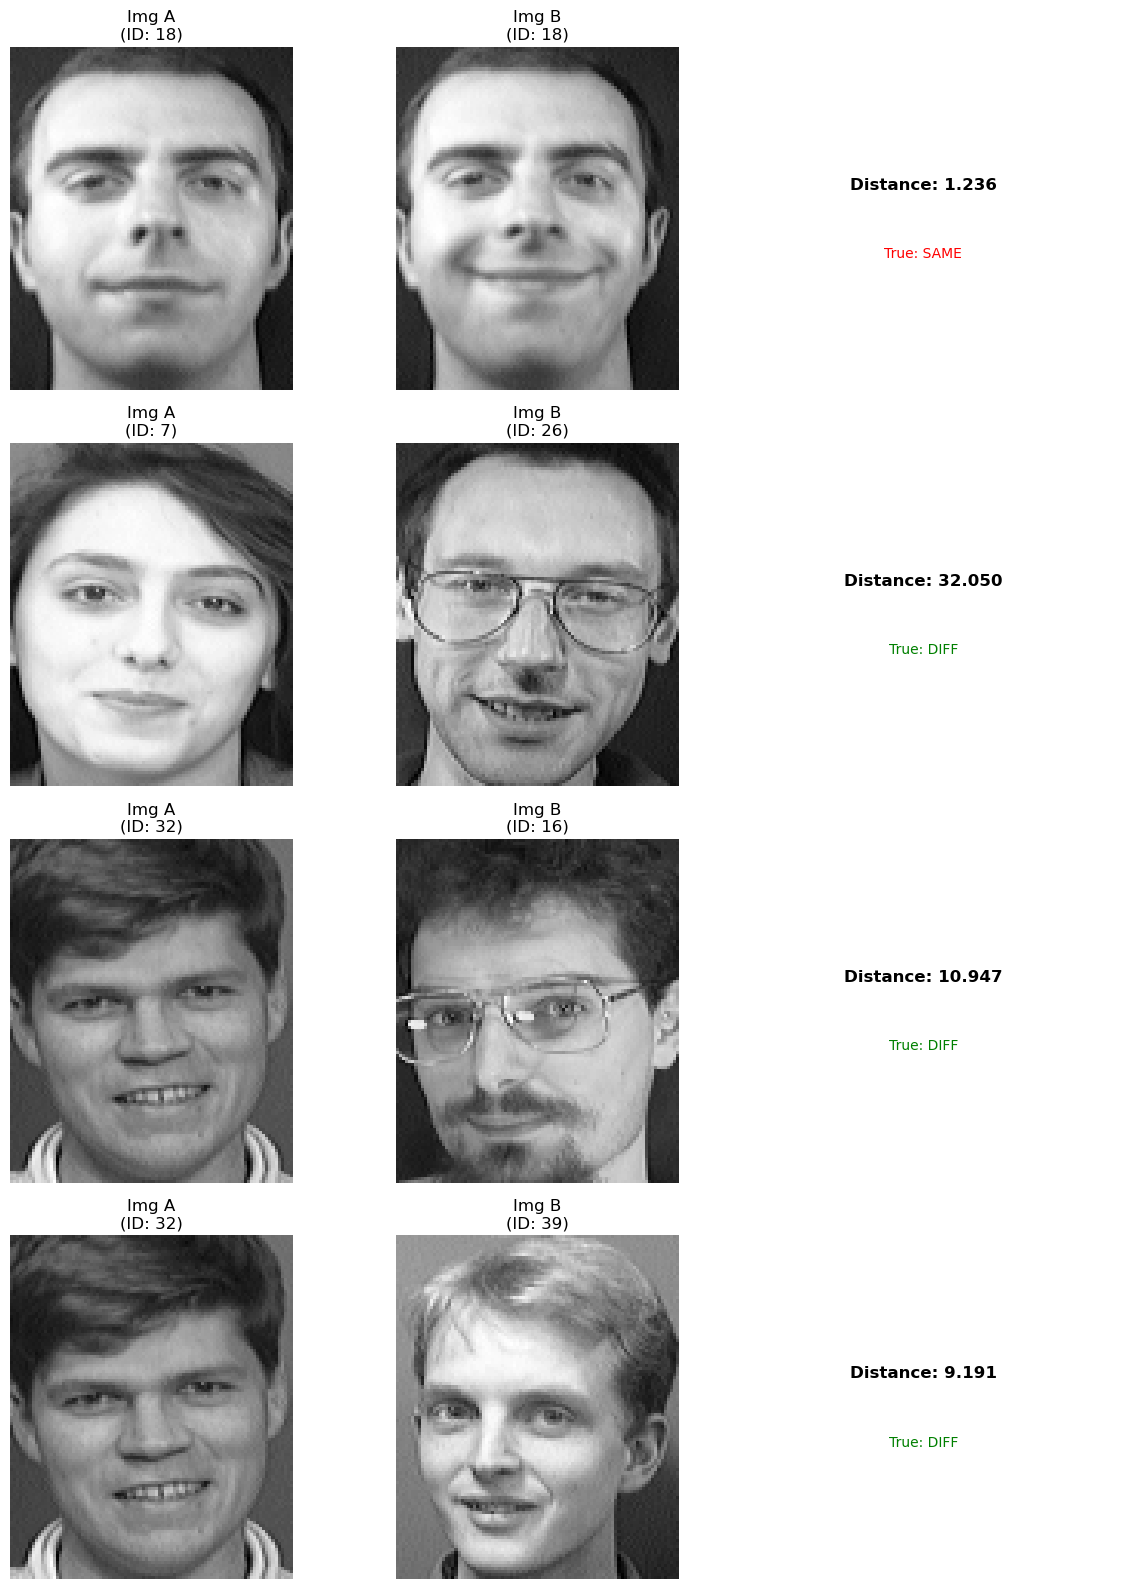

In [ ]:
import torch
import random

import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image
from pathlib import Path
from sklearn.model_selection import train_test_split
from torch.utils.data import Dataset, DataLoader

def load_orl_images(base_dir="/mnt/data/att_faces", img_size=(92, 112)):
    images = []
    labels = []
    for subject_id in range(1, 41):  # 40 субъектов
        subject_dir = Path(base_dir) / f"s{subject_id}"
        for img_id in range(1, 11):  # 10 изображений на субъекта
            img_path = subject_dir / f"{img_id}.pgm"
            if img_path.exists():
                img = Image.open(img_path).convert("L")  # grayscale
                img_array = np.array(img, dtype=np.float32) / 255.0  # normalize [0,1]
                images.append(img_array)
                labels.append(subject_id - 1)  # 0-indexed labels

    return np.array(images), np.array(labels)

class FaceEncoder(nn.Module):

    def __init__(self, embedding_dim=128):
        super(FaceEncoder, self).__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.Conv2d(32, 32, 3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 46x56
            # Block 2
            nn.Conv2d(32, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.Conv2d(64, 64, 3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 23x28
            # Block 3
            nn.Conv2d(64, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.Conv2d(128, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2, 2),  # 11x14
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 11 * 14, 512),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(512, embedding_dim),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


class SiameseNetwork(nn.Module):

    def __init__(self, embedding_dim=128):
        super(SiameseNetwork, self).__init__()
        self.encoder = FaceEncoder(embedding_dim)

    def forward_once(self, x):
        return self.encoder(x)

    def forward(self, x1, x2):
        emb1 = self.forward_once(x1)
        emb2 = self.forward_once(x2)
        return emb1, emb2

    def get_embedding(self, x):
        return self.encoder(x)

def create_pairs(images, labels, num_pairs=5000, same_prob=0.5):
    pairs = []
    targets = []

    unique_labels = np.unique(labels)

    for _ in range(num_pairs):
        if random.random() < same_prob:
            # Same class pair
            label = random.choice(unique_labels)
            indices = np.where(labels == label)[0]
            idx1, idx2 = random.sample(list(indices), 2)
            pairs.append((images[idx1], images[idx2]))
            targets.append(1.0)  
        else:
            # Different class pair
            label1, label2 = random.sample(list(unique_labels), 2)
            idx1 = random.choice(np.where(labels == label1)[0])
            idx2 = random.choice(np.where(labels == label2)[0])
            pairs.append((images[idx1], images[idx2]))
            targets.append(0.0)  

    return pairs, np.array(targets)


class SiameseDataset(Dataset):
    def __init__(self, pairs, targets, transform=None):
        self.pairs = pairs
        self.targets = targets
        self.transform = transform

    def __len__(self):
        return len(self.pairs)

    def __getitem__(self, idx):
        img1, img2 = self.pairs[idx]
        label = self.targets[idx]

        img1 = torch.from_numpy(img1).float()
        img2 = torch.from_numpy(img2).float()

        if img1.dim() == 2:
            img1 = img1.unsqueeze(0)
        if img2.dim() == 2:
            img2 = img2.unsqueeze(0)

        return img1, img2, torch.tensor(label, dtype=torch.float32)


def contrastive_loss(embedding1, embedding2, label, margin=1.0):

    #label: 1 if same class, 0 if different
    
    distance = F.pairwise_distance(embedding1, embedding2, p=2)

    loss = label * torch.pow(distance, 2) + (1 - label) * torch.pow(
        torch.clamp(margin - distance, min=0.0), 2
    )

    return loss.mean()


def bce_with_distance_loss(embedding1, embedding2, label):
    #BCE Loss на основе евклидова расстояния (через sigmoid)
    distance = F.pairwise_distance(embedding1, embedding2, p=2)
    similarity_prob = torch.sigmoid(-distance)  # invert: small dist -> high prob

    return F.binary_cross_entropy(similarity_prob, label)

def train_siamese(loss_type="bce", epochs=50, batch_size=32, lr=1e-3):
    X, y = load_orl_images()
    X = X.reshape(-1, 1, 112, 92)  
    train_idx, test_idx = train_test_split(
        np.arange(len(y)), test_size=0.3, stratify=y, random_state=42
    )

    X_train, y_train = X[train_idx], y[train_idx]
    X_test, y_test = X[test_idx], y[test_idx]

    train_pairs, train_targets = create_pairs(X_train, y_train, num_pairs=8000)
    train_dataset = SiameseDataset(train_pairs, train_targets)
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = SiameseNetwork(embedding_dim=128).to(device)
    optimizer = optim.Adam(model.parameters(), lr=lr)

    # Training loop
    for epoch in range(epochs):
        model.train()
        total_loss = 0

        for img1, img2, labels in train_loader:
            img1, img2, labels = img1.to(device), img2.to(device), labels.to(device)

            optimizer.zero_grad()
            emb1, emb2 = model(img1, img2)

            if loss_type == "bce":
                loss = bce_with_distance_loss(emb1, emb2, labels)
            else:  # contrastive
                loss = contrastive_loss(emb1, emb2, labels, margin=1.0)

            loss.backward()
            optimizer.step()
            total_loss += loss.item()

        if (epoch + 1) % 10 == 0:
            avg_loss = total_loss / len(train_loader)
            print(f"Epoch {epoch+1}/{epochs}, Loss: {avg_loss:.4f}")

    return model, X_test, y_test


def visualize_pairs(model, X_test, y_test, n_pairs=10):
    model.eval()
    device = next(model.parameters()).device

    fig, axes = plt.subplots(n_pairs, 3, figsize=(12, 4 * n_pairs))

    for i in range(n_pairs):
        if np.random.random() < 0.5:
            label = np.random.choice(np.unique(y_test))
            indices = np.where(y_test == label)[0]
            idx1, idx2 = np.random.choice(indices, 2, replace=False)
            true_label = "SAME"
        else:
            labels_pool = np.random.choice(np.unique(y_test), 2, replace=False)
            idx1 = np.random.choice(np.where(y_test == labels_pool[0])[0])
            idx2 = np.random.choice(np.where(y_test == labels_pool[1])[0])
            true_label = "DIFF"

        img1 = torch.tensor(X_test[idx1], dtype=torch.float32).unsqueeze(0).to(device)
        img2 = torch.tensor(X_test[idx2], dtype=torch.float32).unsqueeze(0).to(device)

        with torch.no_grad():
            emb1, emb2 = model(img1, img2)
            distance = torch.pairwise_distance(emb1, emb2, p=2).item()

        axes[i, 0].imshow(X_test[idx1][0], cmap="gray")
        axes[i, 0].set_title(f"Img A\n(ID: {y_test[idx1]})")
        axes[i, 0].axis("off")

        axes[i, 1].imshow(X_test[idx2][0], cmap="gray")
        axes[i, 1].set_title(f"Img B\n(ID: {y_test[idx2]})")
        axes[i, 1].axis("off")

        axes[i, 2].axis("off")
        axes[i, 2].text(
            0.5,
            0.6,
            f"Distance: {distance:.3f}",
            ha="center",
            va="center",
            fontsize=12,
            fontweight="bold",
        )
        axes[i, 2].text(
            0.5,
            0.4,
            f"True: {true_label}",
            ha="center",
            va="center",
            fontsize=10,
            color=(
                "green"
                if (true_label == "SAME" and distance < 1.0)
                or (true_label == "DIFF" and distance > 1.0)
                else "red"
            ),
        )

    plt.tight_layout()
    plt.show()

X, y = load_orl_images()

model, X_test, y_test = train_siamese(loss_type="bce", epochs=5, batch_size=16)

visualize_pairs(model, X_test, y_test, n_pairs=4)

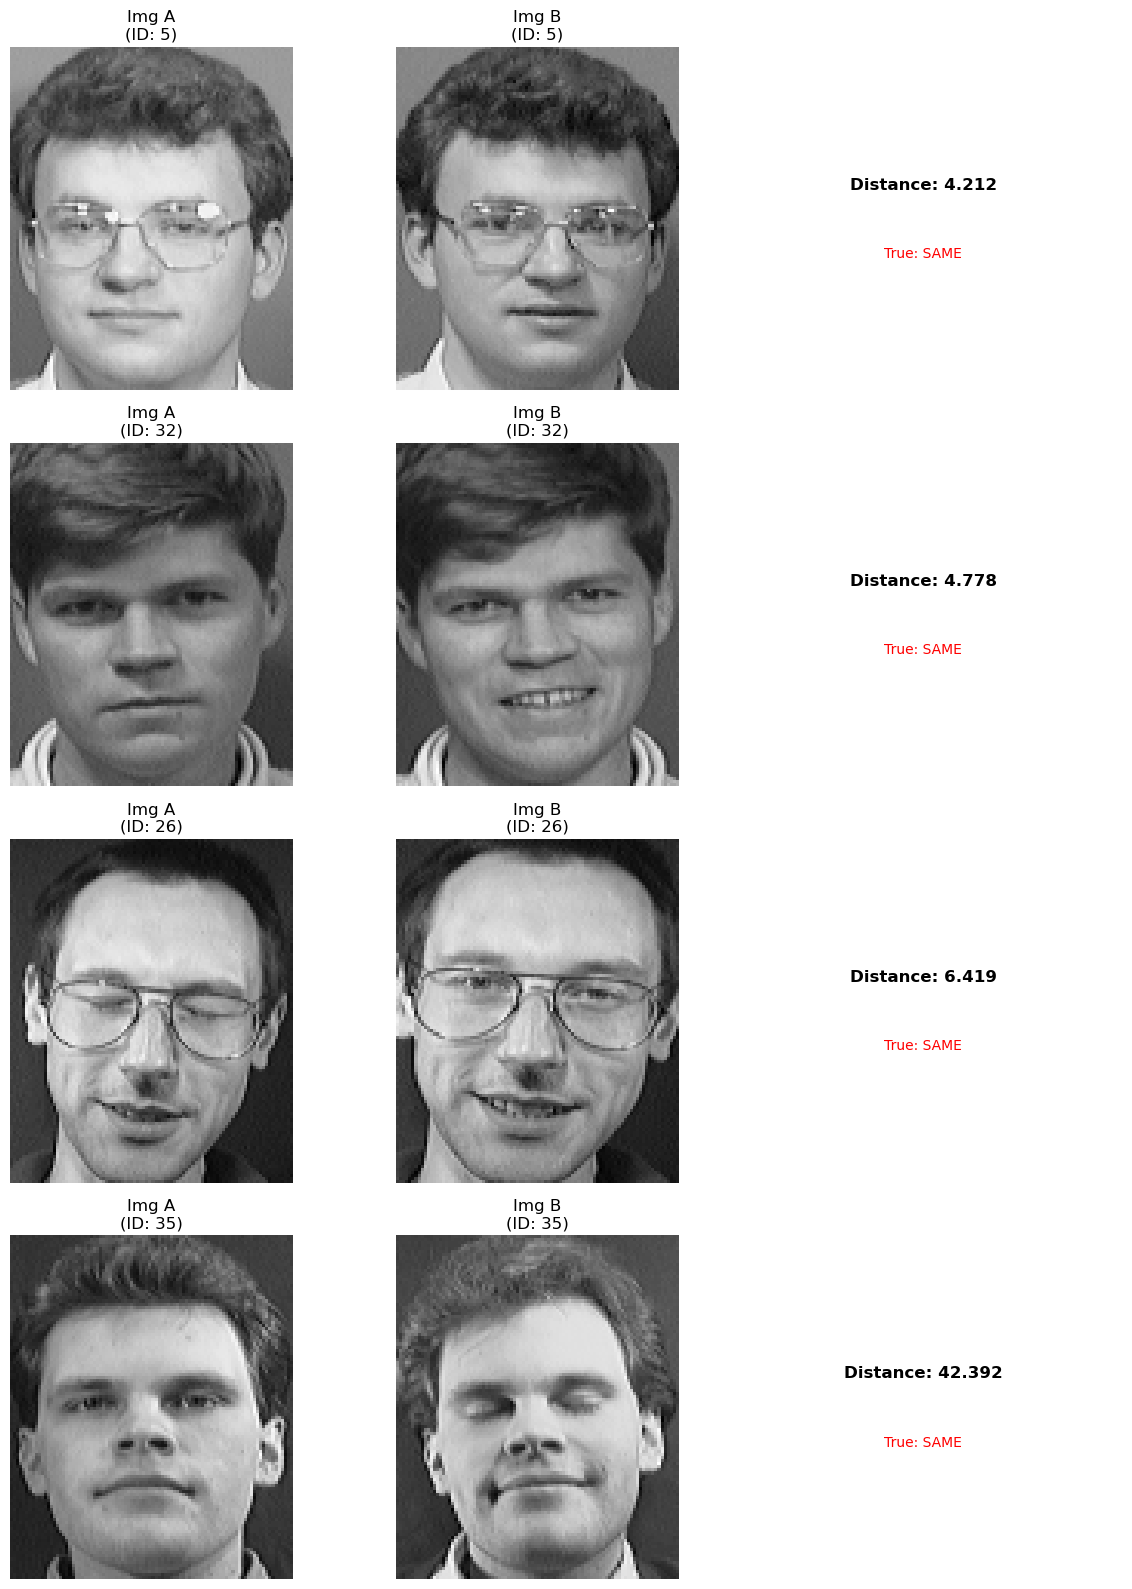

In [18]:
visualize_pairs(model, X_test, y_test, n_pairs=4)

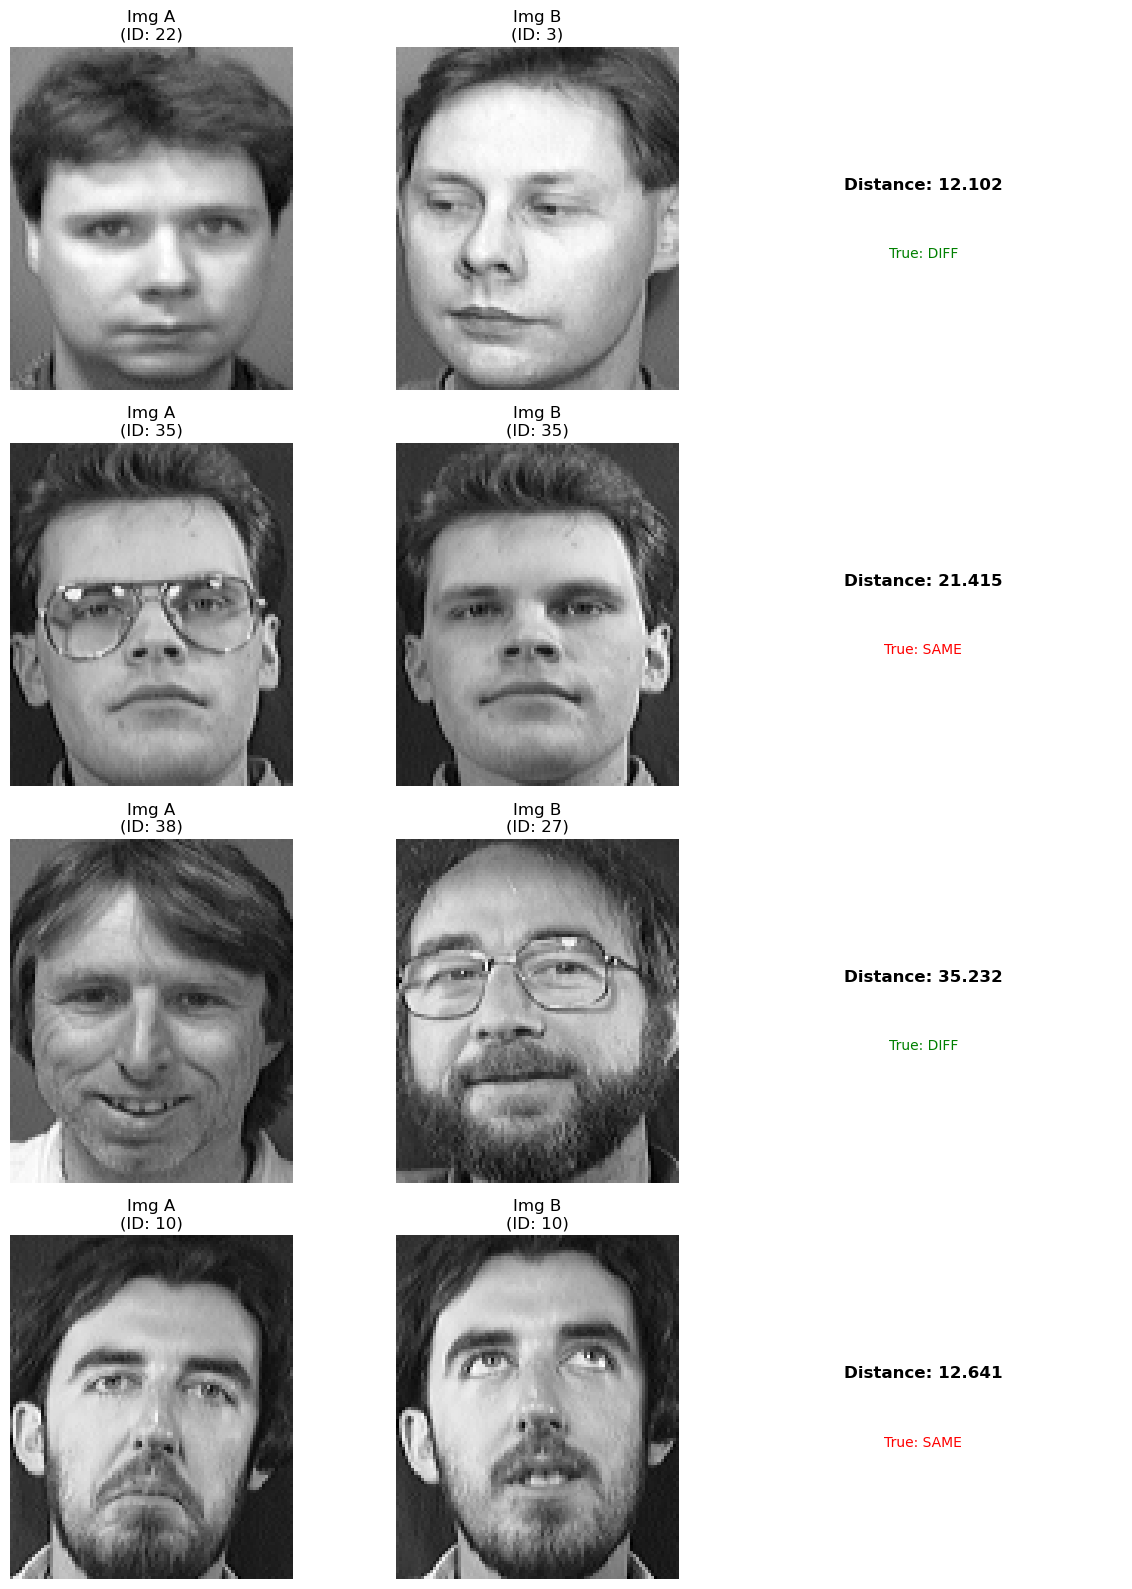

In [21]:
visualize_pairs(model, X_test, y_test, n_pairs=4)

SiameseNetwork(
  (encoder): FaceEncoder(
    (features): Sequential(
      (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): Conv2d(32, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (4): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (5): ReLU(inplace=True)
      (6): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
      (7): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (8): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (9): ReLU(inplace=True)
      (10): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (11): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (12): ReLU(inplace=True)
      (13): MaxPool2d(kernel_size=2, stride=2, pad